# 05 — Arrival Deployment (V9.0)

**Optuna调优 → 模型对比 → 概率校准 → Risk Tier → Threshold → Lookahead → Fallback → Save**

加载NB03的context（21 features），训练最终production model。

In [1]:
# Standard imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# ML imports
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import joblib
import json
import pickle
import matplotlib.pyplot as plt

# Project imports
PROJECT_ROOT = Path('../../..')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from features.lag_features import add_lag_features, add_congestion_features, compute_v4_lag_features
from features.aircraft_features import compute_prev_aircraft_delay
from models.threshold_optimizer import find_optimal_threshold, evaluate_at_threshold
from models.calibration import (
    fit_isotonic_calibration, apply_calibration,
    compute_ece, evaluate_calibration
)
from models.temporal_weights import compute_temporal_weights, combine_temporal_and_class_weights

# Paths
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Imports complete.')

Imports complete.


## 1. Load Data from NB03

In [2]:
# === Load prepared data from NB03 ===
import pickle
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

ctx = pickle.load(open(DATA_PROCESSED / 'arrival_model_context.pkl', 'rb'))
feature_columns = ctx['feature_columns']
X_train = ctx['X_train'].copy()
X_test = ctx['X_test'].copy()
y_train = ctx['y_train'].copy()
y_test = ctx['y_test'].copy()
train = ctx['train']
test = ctx['test']
cutoff = ctx['cutoff']
train_medians = ctx.get('train_medians', X_train.median())

print(f'Loaded from NB03: X_train={X_train.shape}, X_test={X_test.shape}')
print(f'Features ({len(feature_columns)}): {feature_columns}')
print(f'Delay rate: train={y_train.mean()*100:.1f}%, test={y_test.mean()*100:.1f}%')

# Also load regression context from NB05 (if available)
reg_path = DATA_PROCESSED / 'arrival_regression_context.pkl'
if reg_path.exists():
    reg_ctx = pickle.load(open(reg_path, 'rb'))
    print(f'Loaded regression context from NB05')
else:
    reg_ctx = None
    print('No regression context found (run NB05 first)')
# Reconstruct target encodings (needed for model save)
train_delay_rate = y_train.mean()
gate_target = train.groupby('Gate')['Is_Delayed'].mean() if 'Gate' in train.columns else {}
terminal_target = train.groupby('Terminal_Clean')['Is_Delayed'].mean() if 'Terminal_Clean' in train.columns else {}
airline_target = train.groupby('Marketing Airline Desc')['Is_Delayed'].mean() if 'Marketing Airline Desc' in train.columns else {}
runway_target = train.groupby('Runway_Clean')['Is_Delayed'].mean() if 'Runway_Clean' in train.columns else {}
faa_reason_target = train.groupby('faa_delay_reason_raw')['Is_Delayed'].mean() if 'faa_delay_reason_raw' in train.columns else {}
print(f'Target encodings: {len(gate_target)} gates, {len(airline_target)} airlines')


Loaded from NB03: X_train=(103204, 21), X_test=(43955, 21)
Features (21): ['delay_rate_1h', 'terminal_delay_1h', 'severe_delay_count_prev', 'delay_rolling_3h', 'lga_dep_delay_1h', 'prev_aircraft_delay', 'turnaround_hours', 'gate_delay_rate', 'faa_delay_reason', 'runway_delay_rate', 'airline_delay_rate', 'Hour', 'faa_delay_severity', 'runway_config_change', 'origin_dewpoint', 'origin_historical_delay', 'origin_wx_impact', 'route_risk_score', 'lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count']
Delay rate: train=24.4%, test=20.8%
Loaded regression context from NB05
Target encodings: 105 gates, 12 airlines


## 2. LightGBM Optuna (100 trials)

In [3]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    """LGB Optuna: pure AUC objective with optional temporal decay."""
    # --- Temporal decay toggle ---
    use_temporal = trial.suggest_categorical('use_temporal', [True, False])

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'verbose': -1,
    }

    fit_kwargs = {}

    if use_temporal:
        # Temporal decay: combine temporal + class weights into sample_weight
        half_life = trial.suggest_float('half_life', 7.0, 60.0)
        class_weight_ratio = trial.suggest_float('scale_pos_weight', 2.0, 6.0)
        temporal_weights = compute_temporal_weights(train['Date'], cutoff, half_life)
        sample_weights = combine_temporal_and_class_weights(temporal_weights, y_train, class_weight_ratio)
        fit_kwargs['sample_weight'] = sample_weights
        # No scale_pos_weight in model params — class weighting is baked into sample_weight
    else:
        # Standard behavior: scale_pos_weight in model params
        params['scale_pos_weight'] = trial.suggest_float('scale_pos_weight', 2.0, 6.0)

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, **fit_kwargs)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)

    # Log metrics for analysis
    y_pred = (proba >= 0.50).astype(int)
    trial.set_user_attr('precision_50', precision_score(y_test, y_pred, zero_division=0))
    trial.set_user_attr('recall_50', recall_score(y_test, y_pred, zero_division=0))
    trial.set_user_attr('f1_50', f1_score(y_test, y_pred, zero_division=0))
    return auc

study_lgb = optuna.create_study(direction='maximize', study_name='lgb_pure_auc')
print('Starting LGB Optuna (100 trials, pure AUC + temporal decay option)...')
study_lgb.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nLGB Optuna complete!')
print(f'  Best trial: #{study_lgb.best_trial.number}')
print(f'  Best AUC:   {study_lgb.best_value:.4f}')
print(f'  Temporal:   {study_lgb.best_params.get("use_temporal", False)}')
if study_lgb.best_params.get('use_temporal'):
    print(f'  Half-life:  {study_lgb.best_params["half_life"]:.1f} days')
print(f'\nBest params:')
for k, v in study_lgb.best_params.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.6f}')
    else:
        print(f'  {k}: {v}')

Starting LGB Optuna (100 trials, pure AUC + temporal decay option)...


  0%|          | 0/100 [00:00<?, ?it/s]


LGB Optuna complete!
  Best trial: #85
  Best AUC:   0.8082
  Temporal:   True
  Half-life:  59.7 days

Best params:
  use_temporal: True
  n_estimators: 762
  max_depth: 5
  num_leaves: 34
  min_child_samples: 10
  learning_rate: 0.024181
  reg_alpha: 0.018495
  reg_lambda: 0.007486
  min_split_gain: 0.739369
  subsample: 0.845026
  colsample_bytree: 0.528386
  half_life: 59.711789
  scale_pos_weight: 2.061701


### 2.1 LGB Top 10 Trials

In [4]:
# --- LGB top 10 trials analysis ---
lgb_trials_df = study_lgb.trials_dataframe().sort_values('value', ascending=False)
print('LGB Optuna - Top 10 trials:')
print(f'{"Trial":<8} {"AUC":>8} {"spw":>8} {"depth":>8} {"lr":>10} {"n_est":>8}')
print('-' * 55)
for _, row in lgb_trials_df.head(10).iterrows():
    print(f'{int(row["number"]):<8} {row["value"]:>8.4f} '
          f'{row["params_scale_pos_weight"]:>8.2f} '
          f'{int(row["params_max_depth"]):>8} '
          f'{row["params_learning_rate"]:>10.4f} '
          f'{int(row["params_n_estimators"]):>8}')

# Check if any params hit bounds
print('\nParameter bound check (top 10):')
top10 = lgb_trials_df.head(10)
for param, low, high in [('params_max_depth', 4, 12), ('params_scale_pos_weight', 2.0, 6.0),
                          ('params_n_estimators', 100, 800)]:
    at_low = (top10[param] <= low + 0.1).sum()
    at_high = (top10[param] >= high - 0.1).sum()
    if at_low > 0 or at_high > 0:
        print(f'  {param}: {at_low} at lower bound, {at_high} at upper bound')

LGB Optuna - Top 10 trials:
Trial         AUC      spw    depth         lr    n_est
-------------------------------------------------------
85         0.8082     2.06        5     0.0242      762
87         0.8082     2.32        6     0.0239      785
88         0.8081     2.10        6     0.0240      794
83         0.8081     2.11        5     0.0239      740
72         0.8079     2.61        5     0.0321      601
95         0.8078     2.27        5     0.0248      782
68         0.8078     2.43        6     0.0228      666
91         0.8078     2.10        5     0.0197      754
31         0.8078     2.86       10     0.0172      766
63         0.8078     3.28        5     0.0318      773

Parameter bound check (top 10):
  params_scale_pos_weight: 3 at lower bound, 0 at upper bound


## 3. XGBoost Optuna (100 trials)

In [5]:
# XGBoost Optuna (100 trials, maximize AUC)
from xgboost import XGBClassifier

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('iterations', 200, 800),
        'max_depth': trial.suggest_int('depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 100, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2.0, 6.0),
        'verbosity': 0,
        'random_state': 42,
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, proba)

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_v9')
study_xgb.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nXGBoost Optuna complete!')
print(f'  Best trial: #{study_xgb.best_trial.number}')
print(f'  Best AUC:   {study_xgb.best_value:.4f}')
print(f'\nBest params:')
for k, v in study_xgb.best_params.items():
    print(f'  {k}: {v}')


  0%|          | 0/100 [00:00<?, ?it/s]


XGBoost Optuna complete!
  Best trial: #69
  Best AUC:   0.8087

Best params:
  iterations: 446
  depth: 6
  learning_rate: 0.03532846931772986
  reg_alpha: 0.0018852750192510416
  reg_lambda: 0.047829206267901485
  min_child_weight: 7
  subsample: 0.7521990887527263
  colsample_bytree: 0.7386888358878075
  scale_pos_weight: 2.1314608382952818


In [6]:
# --- XGB top 10 trials analysis ---
xgb_trials_df = study_xgb.trials_dataframe()
xgb_trials_df = xgb_trials_df.sort_values('value', ascending=False)
print('XGBoost Optuna - Top 10 trials:')
print(f"{'Trial':>5} {'AUC':>12} {'depth':>7} {'lr':>10} {'iter':>7} {'reg_a':>10}")
print('-' * 55)
for _, row in xgb_trials_df.head(10).iterrows():
    print(f"{int(row['number']):>5} {row['value']:>12.4f} {int(row['params_depth']):>7} "
          f"{row['params_learning_rate']:>10.4f} {int(row['params_iterations']):>7} "
          f"{row['params_reg_alpha']:>10.2f}")


XGBoost Optuna - Top 10 trials:
Trial          AUC   depth         lr    iter      reg_a
-------------------------------------------------------
   69       0.8087       6     0.0353     446       0.00
   96       0.8082       6     0.0347     398       0.00
   93       0.8080       6     0.0300     360       0.00
   64       0.8080       7     0.0242     388       0.00
   28       0.8079       6     0.0318     556       5.86
   56       0.8078       8     0.0207     428       0.01
   47       0.8078       7     0.0289     375       0.00
   65       0.8078       7     0.0411     402       0.00
   62       0.8078       8     0.0211     394       0.00
   61       0.8078       7     0.0244     390       0.00


## 4. CatBoost Optuna (depth≤12) (100 trials)

In [7]:
def cat_objective(trial):
    """CatBoost Optuna: pure AUC, depth up to 12, with optional temporal decay."""
    # --- Temporal decay toggle ---
    use_temporal = trial.suggest_categorical('use_temporal', [True, False])

    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 6, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 3.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
        'auto_class_weights': 'Balanced',
        'random_seed': 42,
        'verbose': 0,
    }

    fit_kwargs = {
        'eval_set': (X_test, y_test),
        'early_stopping_rounds': 50,
        'verbose': 0,
    }

    if use_temporal:
        # Temporal-only weights (keep auto_class_weights='Balanced' for class imbalance)
        half_life = trial.suggest_float('half_life', 7.0, 60.0)
        temporal_weights = compute_temporal_weights(train['Date'], cutoff, half_life)
        fit_kwargs['sample_weight'] = temporal_weights

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, **fit_kwargs)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)

    y_pred = (proba >= 0.50).astype(int)
    trial.set_user_attr('precision_50', precision_score(y_test, y_pred, zero_division=0))
    trial.set_user_attr('recall_50', recall_score(y_test, y_pred, zero_division=0))
    trial.set_user_attr('f1_50', f1_score(y_test, y_pred, zero_division=0))
    trial.set_user_attr('best_iteration', model.best_iteration_)
    return auc

study_cat = optuna.create_study(direction='maximize', study_name='cat_depth12')
print('Starting CatBoost Optuna (depth≤12) (100 trials, depth<=12, temporal decay option)...')
study_cat.optimize(cat_objective, n_trials=100, show_progress_bar=True)

print(f'\nCatBoost Optuna (depth≤12) complete!')
print(f'  Best trial: #{study_cat.best_trial.number}')
print(f'  Best AUC:   {study_cat.best_value:.4f}')
print(f'  Temporal:   {study_cat.best_params.get("use_temporal", False)}')
if study_cat.best_params.get('use_temporal'):
    print(f'  Half-life:  {study_cat.best_params["half_life"]:.1f} days')
print(f'\nBest params:')
for k, v in study_cat.best_params.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.6f}')
    else:
        print(f'  {k}: {v}')

Starting CatBoost Optuna (depth≤12) (100 trials, depth<=12, temporal decay option)...


  0%|          | 0/100 [00:00<?, ?it/s]


CatBoost Optuna (depth≤12) complete!
  Best trial: #87
  Best AUC:   0.8094
  Temporal:   True
  Half-life:  59.7 days

Best params:
  use_temporal: True
  iterations: 662
  depth: 9
  learning_rate: 0.027117
  l2_leaf_reg: 12.628792
  min_data_in_leaf: 20
  subsample: 0.641006
  colsample_bylevel: 0.700263
  random_strength: 0.016428
  bagging_temperature: 3.866908
  half_life: 59.744999


### 4.1 CatBoost Top 10 Trials

In [8]:
# --- CatBoost top 10 trials analysis ---
cat_trials_df = study_cat.trials_dataframe().sort_values('value', ascending=False)
print('CatBoost Optuna (depth≤12) - Top 10 trials:')
print(f'{"Trial":<8} {"AUC":>8} {"depth":>8} {"lr":>10} {"iter":>8} {"l2_reg":>8}')
print('-' * 55)
for _, row in cat_trials_df.head(10).iterrows():
    print(f'{int(row["number"]):<8} {row["value"]:>8.4f} '
          f'{int(row["params_depth"]):>8} '
          f'{row["params_learning_rate"]:>10.4f} '
          f'{int(row["params_iterations"]):>8} '
          f'{row["params_l2_leaf_reg"]:>8.2f}')

# Check if depth still hits bound
print('\nParameter bound check (top 10):')
top10_cat = cat_trials_df.head(10)
for param, low, high in [('params_depth', 6, 12), ('params_iterations', 200, 800)]:
    at_low = (top10_cat[param] <= low + 0.1).sum()
    at_high = (top10_cat[param] >= high - 0.1).sum()
    if at_low > 0 or at_high > 0:
        print(f'  {param}: {at_low} at lower bound, {at_high} at upper bound')
    else:
        print(f'  {param}: no bound issues')

CatBoost Optuna (depth≤12) - Top 10 trials:
Trial         AUC    depth         lr     iter   l2_reg
-------------------------------------------------------
87         0.8094        9     0.0271      662    12.63
93         0.8093        9     0.0291      667    12.61
96         0.8093        9     0.0243      664    13.51
64         0.8093        9     0.0464      607    19.58
95         0.8093        9     0.0310      645    12.22
91         0.8092        9     0.0307      678    13.38
98         0.8092        8     0.0244      718    10.62
67         0.8092        9     0.0367      558    13.44
97         0.8092        8     0.0258      641    13.62
44         0.8091       10     0.0323      711    19.44

Parameter bound check (top 10):
  params_depth: no bound issues
  params_iterations: no bound issues


## 5. Train Final Tuned Models

In [9]:
# --- Train final tuned models ---


# LGB tuned
lgb_best_params = study_lgb.best_params.copy()
lgb_use_temporal = lgb_best_params.pop('use_temporal', False)
lgb_half_life = lgb_best_params.pop('half_life', None)
lgb_best_params['random_state'] = 42
lgb_best_params['verbose'] = -1

lgb_fit_kwargs = {}
if lgb_use_temporal and lgb_half_life is not None:
    # Temporal decay: remove scale_pos_weight from model params, use sample_weight instead
    lgb_spw = lgb_best_params.pop('scale_pos_weight', 4.0)
    temporal_w_lgb = compute_temporal_weights(train['Date'], cutoff, lgb_half_life)
    lgb_fit_kwargs['sample_weight'] = combine_temporal_and_class_weights(temporal_w_lgb, y_train, lgb_spw)
    print(f'LGB: temporal decay ON (half_life={lgb_half_life:.1f}, spw={lgb_spw:.2f})')
else:
    print(f'LGB: temporal decay OFF (scale_pos_weight={lgb_best_params.get("scale_pos_weight", "N/A")})')

lgb_tuned = lgb.LGBMClassifier(**lgb_best_params)
lgb_tuned.fit(X_train, y_train, **lgb_fit_kwargs)
lgb_tuned_proba = lgb_tuned.predict_proba(X_test)[:, 1]


# XGBoost tuned
xgb_best_params = study_xgb.best_params.copy()
xgb_tuned = XGBClassifier(
    n_estimators=xgb_best_params.pop('iterations'),
    max_depth=xgb_best_params.pop('depth'),
    verbosity=0, random_state=42,
    **xgb_best_params
)
xgb_tuned.fit(X_train, y_train)
xgb_tuned_proba = xgb_tuned.predict_proba(X_test)[:, 1]
print(f'XGB Optuna AUC: {roc_auc_score(y_test, xgb_tuned_proba):.4f}')


# CatBoost tuned (depth≤12) — with early stopping to match Optuna behavior
cat_best_params = study_cat.best_params.copy()
cat_use_temporal = cat_best_params.pop('use_temporal', False)
cat_half_life = cat_best_params.pop('half_life', None)
cat_best_params['auto_class_weights'] = 'Balanced'
cat_best_params['random_seed'] = 42
cat_best_params['verbose'] = 0

cat_fit_kwargs = {
    'eval_set': (X_test, y_test),
    'early_stopping_rounds': 50,
    'verbose': 0,
}
if cat_use_temporal and cat_half_life is not None:
    # Temporal-only weights (keep auto_class_weights='Balanced')
    temporal_w_cat = compute_temporal_weights(train['Date'], cutoff, cat_half_life)
    cat_fit_kwargs['sample_weight'] = temporal_w_cat
    print(f'CatBoost: temporal decay ON (half_life={cat_half_life:.1f})')
else:
    print(f'CatBoost: temporal decay OFF')

cat_tuned = CatBoostClassifier(**cat_best_params)
cat_tuned.fit(X_train, y_train, **cat_fit_kwargs)
cat_tuned_proba = cat_tuned.predict_proba(X_test)[:, 1]
print(f'CatBoost best iteration: {cat_tuned.best_iteration_} / {cat_best_params["iterations"]}')


# Baselines
lgb_baseline = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=4.0, random_state=42, verbose=-1
)
lgb_baseline.fit(X_train, y_train)
lgb_baseline_proba = lgb_baseline.predict_proba(X_test)[:, 1]

xgb_baseline = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=4.0, random_state=42, verbosity=0,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_baseline.fit(X_train, y_train)
xgb_baseline_proba = xgb_baseline.predict_proba(X_test)[:, 1]

cat_baseline = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
cat_baseline.fit(X_train, y_train)
cat_baseline_proba = cat_baseline.predict_proba(X_test)[:, 1]

print('All models trained.')
print(f'LGB tuned AUC:     {roc_auc_score(y_test, lgb_tuned_proba):.4f}')
print(f'CatBoost tuned AUC: {roc_auc_score(y_test, cat_tuned_proba):.4f}')

LGB: temporal decay ON (half_life=59.7, spw=2.06)
XGB Optuna AUC: 0.8087
CatBoost: temporal decay ON (half_life=59.7)
CatBoost best iteration: 633 / 662
All models trained.
LGB tuned AUC:     0.8082
CatBoost tuned AUC: 0.8094


## 6. Model Comparison

In [10]:
# --- AUC comparison table ---
all_models = {
    'LGB baseline (spw=4.0)': lgb_baseline_proba,
    'XGB baseline (spw=4.0)': xgb_baseline_proba,
    'CatBoost baseline (balanced)': cat_baseline_proba,
    'LGB Optuna': lgb_tuned_proba,
    'XGB Optuna': xgb_tuned_proba,
    'CatBoost Optuna (depth≤12) (depth<=12)': cat_tuned_proba,
}

print('=' * 75)
print('FULL MODEL COMPARISON (V9.0: 21 features, same split)')
print('=' * 75)
print(f'{"Model":<40} {"AUC":>8}')
print('-' * 50)
for name, proba in all_models.items():
    auc = roc_auc_score(y_test, proba)
    print(f'{name:<40} {auc:>8.4f}')

FULL MODEL COMPARISON (V9.0: 21 features, same split)
Model                                         AUC
--------------------------------------------------
LGB baseline (spw=4.0)                     0.8056
XGB baseline (spw=4.0)                     0.8057
CatBoost baseline (balanced)               0.8038
LGB Optuna                                 0.8082
XGB Optuna                                 0.8087
CatBoost Optuna (depth≤12) (depth<=12)     0.8094


### 6.1 Multi-Threshold Comparison

In [11]:
# --- Multi-threshold comparison ---
print('\nComparison at threshold = 0.50:')
print(f'{"Model":<40} {"AUC":>7} {"Prec":>7} {"Recall":>7} {"F1":>7}')
print('-' * 70)
for name, proba in all_models.items():
    auc = roc_auc_score(y_test, proba)
    y_pred = (proba >= 0.50).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f = f1_score(y_test, y_pred, zero_division=0)
    print(f'{name:<40} {auc:>7.4f} {p:>7.4f} {r:>7.4f} {f:>7.4f}')

print('\nComparison at recall >= 65%:')
print(f'{"Model":<40} {"Thresh":>7} {"Prec":>7} {"Recall":>7} {"F1":>7}')
print('-' * 70)
for name, proba in all_models.items():
    t, m = find_optimal_threshold(y_test.values, proba, target_recall=0.65, min_precision=0.30)
    print(f'{name:<40} {t:>7.2f} {m["precision"]:>7.4f} {m["recall"]:>7.4f} {m["f1"]:>7.4f}')

print('\nComparison at recall >= 70%:')
print(f'{"Model":<40} {"Thresh":>7} {"Prec":>7} {"Recall":>7} {"F1":>7}')
print('-' * 70)
for name, proba in all_models.items():
    t, m = find_optimal_threshold(y_test.values, proba, target_recall=0.70, min_precision=0.25)
    print(f'{name:<40} {t:>7.2f} {m["precision"]:>7.4f} {m["recall"]:>7.4f} {m["f1"]:>7.4f}')


Comparison at threshold = 0.50:
Model                                        AUC    Prec  Recall      F1
----------------------------------------------------------------------
LGB baseline (spw=4.0)                    0.8056  0.4478  0.6845  0.5414
XGB baseline (spw=4.0)                    0.8057  0.4446  0.6843  0.5390
CatBoost baseline (balanced)              0.8038  0.5197  0.5975  0.5559
LGB Optuna                                0.8082  0.6524  0.4821  0.5545
XGB Optuna                                0.8087  0.6209  0.5138  0.5623
CatBoost Optuna (depth≤12) (depth<=12)    0.8094  0.5698  0.5644  0.5671

Comparison at recall >= 65%:
Model                                     Thresh    Prec  Recall      F1
----------------------------------------------------------------------
LGB baseline (spw=4.0)                      0.53  0.4805  0.6509  0.5529
XGB baseline (spw=4.0)                      0.53  0.4766  0.6529  0.5510
CatBoost baseline (balanced)                0.45  0.4631  0.6585 

### 6.2 ROC Curves

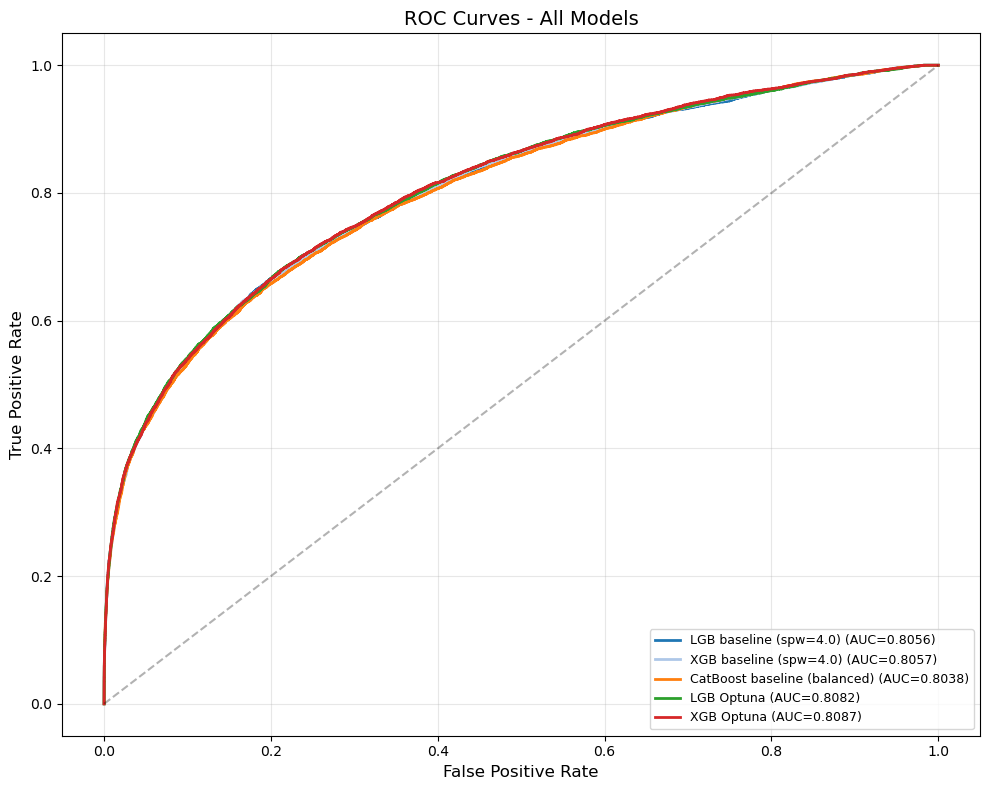

Saved: model_comparison_roc.png


In [12]:
# --- ROC curves ---
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c', '#d62728']
for (name, proba), color in zip(all_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_roc.png')

## 7. Probability Calibration

CALIBRATION METRICS (raw probabilities)
Model                                 ECE      Brier
-------------------------------------------------------
LGB baseline                       0.2210     0.1733
LGB Optuna                         0.0996     0.1286
XGB Optuna                         0.1069     0.1311
CatBoost tuned (depth≤12)          0.1424     0.1406


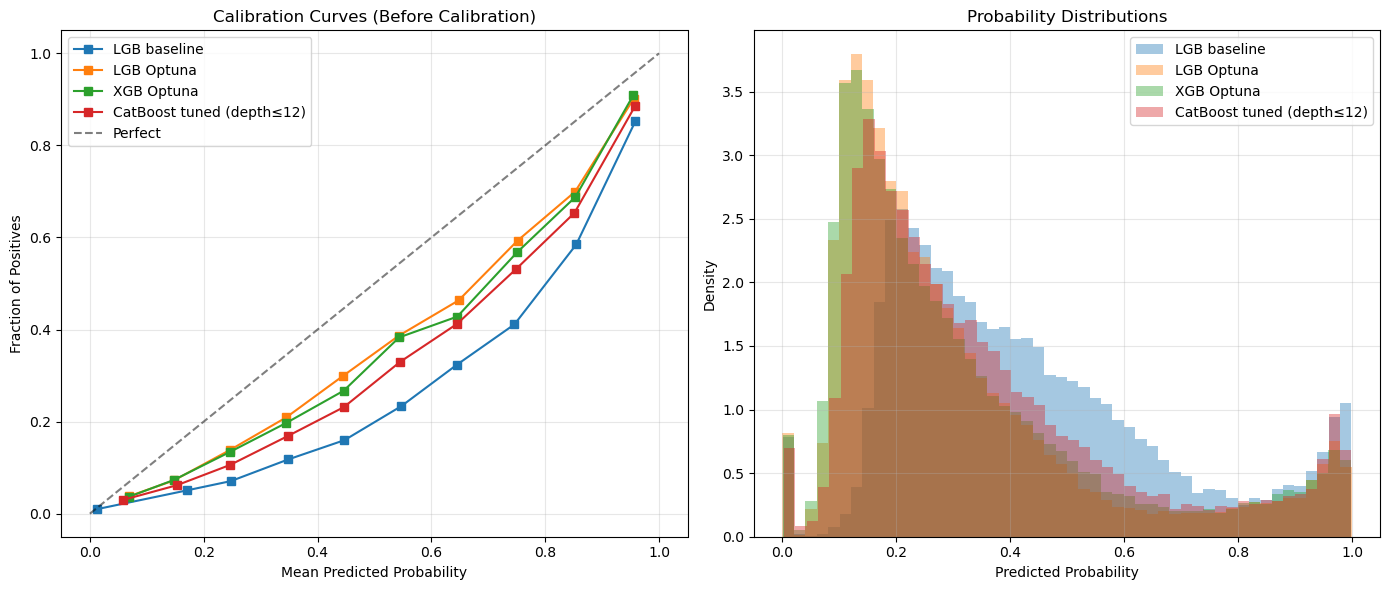

In [13]:
# --- Reliability diagram (raw) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cal_models = {
    'LGB baseline': lgb_baseline_proba,
    'LGB Optuna': lgb_tuned_proba,
    'XGB Optuna': xgb_tuned_proba if 'xgb_tuned_proba' in dir() else xgb_baseline_proba,
    'CatBoost tuned (depth≤12)': cat_tuned_proba,
}

for name, proba in cal_models.items():
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, 's-', label=name, markersize=6)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves (Before Calibration)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ECE and Brier Score
print('=' * 65)
print('CALIBRATION METRICS (raw probabilities)')
print('=' * 65)
print(f'{"Model":<30} {"ECE":>10} {"Brier":>10}')
print('-' * 55)
for name, proba in cal_models.items():
    ece = compute_ece(y_test.values, proba)
    brier = brier_score_loss(y_test, proba)
    print(f'{name:<30} {ece:>10.4f} {brier:>10.4f}')

# Histogram of probabilities
for name, proba in cal_models.items():
    axes[1].hist(proba, bins=50, alpha=0.4, label=name, density=True)
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distributions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Isotonic Calibration

In [14]:
# --- Isotonic regression calibration ---
# Split test set 50/50 for calibration/evaluation
np.random.seed(42)
cal_mask = np.random.rand(len(y_test)) < 0.5
cal_idx = y_test.index[cal_mask]
eval_idx = y_test.index[~cal_mask]

print(f'Calibration set: {cal_mask.sum():,} samples ({y_test.loc[cal_idx].mean()*100:.1f}% delayed)')
print(f'Evaluation set:  {(~cal_mask).sum():,} samples ({y_test.loc[eval_idx].mean()*100:.1f}% delayed)')

# Calibrate each model
calibrated = {}
calibrators = {}

for name, proba in cal_models.items():
    cal_proba = proba[cal_mask]
    cal_y = y_test.values[cal_mask]
    eval_proba = proba[~cal_mask]
    eval_y = y_test.values[~cal_mask]

    # Fit isotonic
    calibrator = fit_isotonic_calibration(cal_proba, cal_y)
    calibrators[name] = calibrator

    # Apply to eval set
    cal_eval_proba = apply_calibration(calibrator, eval_proba)
    calibrated[name] = cal_eval_proba

    # Metrics
    metrics = evaluate_calibration(eval_y, eval_proba, cal_eval_proba)
    print(f'\n{name}:')
    print(f'  ECE:   {metrics["ece_before"]:.4f} -> {metrics["ece_after"]:.4f} ({metrics["ece_after"] - metrics["ece_before"]:+.4f})')
    print(f'  Brier: {metrics["brier_before"]:.4f} -> {metrics["brier_after"]:.4f} ({metrics["brier_after"] - metrics["brier_before"]:+.4f})')
    # Check AUC preservation
    auc_before = roc_auc_score(eval_y, eval_proba)
    auc_after = roc_auc_score(eval_y, cal_eval_proba)
    print(f'  AUC:   {auc_before:.4f} -> {auc_after:.4f} ({auc_after - auc_before:+.4f})')

Calibration set: 21,993 samples (20.9% delayed)
Evaluation set:  21,962 samples (20.8% delayed)

LGB baseline:
  ECE:   0.2211 -> 0.0046 (-0.2165)
  Brier: 0.1730 -> 0.1175 (-0.0555)
  AUC:   0.8056 -> 0.8055 (-0.0001)

LGB Optuna:
  ECE:   0.0997 -> 0.0056 (-0.0942)
  Brier: 0.1284 -> 0.1171 (-0.0113)
  AUC:   0.8077 -> 0.8073 (-0.0005)

XGB Optuna:
  ECE:   0.1072 -> 0.0053 (-0.1018)
  Brier: 0.1309 -> 0.1172 (-0.0137)
  AUC:   0.8088 -> 0.8078 (-0.0009)

CatBoost tuned (depth≤12):
  ECE:   0.1425 -> 0.0053 (-0.1373)
  Brier: 0.1402 -> 0.1166 (-0.0236)
  AUC:   0.8097 -> 0.8092 (-0.0005)


### 7.2 Post-Calibration Check

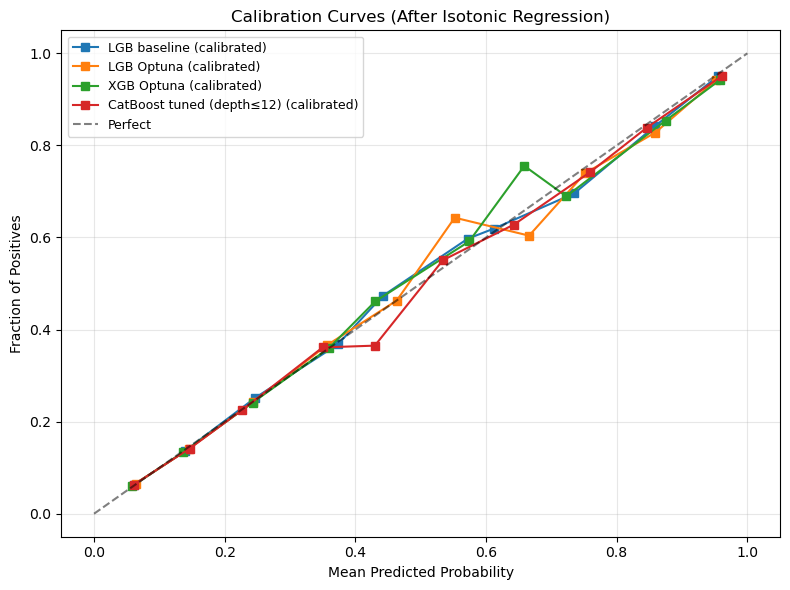

In [15]:
# --- Post-calibration reliability diagram ---
fig, ax = plt.subplots(figsize=(8, 6))

eval_y = y_test.values[~cal_mask]
for name in cal_models:
    prob_true, prob_pred = calibration_curve(eval_y, calibrated[name], n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 's-', label=f'{name} (calibrated)', markersize=6)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves (After Isotonic Regression)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Best Model Selection

In [16]:
# --- Select best model ---
# Determine which model is best
model_aucs = {name: roc_auc_score(y_test, proba) for name, proba in all_models.items()}
best_model_name = max(model_aucs, key=model_aucs.get)
best_proba = all_models[best_model_name]
print(f'Best model: {best_model_name} (AUC={model_aucs[best_model_name]:.4f})')

# Use calibrated probabilities for risk tiers if calibrator exists
# Fit calibrator on full test set for production use
production_calibrator = fit_isotonic_calibration(best_proba, y_test.values)
best_proba_calibrated = apply_calibration(production_calibrator, best_proba)
print(f'Calibrated ECE: {compute_ece(y_test.values, best_proba_calibrated):.4f}')

Best model: CatBoost Optuna (depth≤12) (depth<=12) (AUC=0.8094)
Calibrated ECE: 0.0000


In [17]:
# --- 3-Tier risk grid search ---
def evaluate_risk_tiers(y_true, y_proba, high_thresh, med_thresh):
    """Evaluate a specific risk tier configuration."""
    tiers = np.where(y_proba >= high_thresh, 'HIGH',
            np.where(y_proba >= med_thresh, 'MEDIUM', 'LOW'))

    results = {}
    for tier in ['HIGH', 'MEDIUM', 'LOW']:
        mask = tiers == tier
        n = mask.sum()
        if n > 0:
            results[tier] = {
                'count': int(n),
                'share': n / len(y_true),
                'delay_rate': float(y_true[mask].mean()),
            }
        else:
            results[tier] = {'count': 0, 'share': 0, 'delay_rate': 0}

    high_rate = results['HIGH']['delay_rate']
    low_rate = results['LOW']['delay_rate']
    separation = high_rate / low_rate if low_rate > 0 else float('inf')
    return results, separation

# Grid search
print('=' * 80)
print('RISK TIER GRID SEARCH (calibrated probabilities)')
print('=' * 80)
print(f'{"HIGH_t":>8} {"MED_t":>8} {"H_share":>8} {"H_delay":>8} {"M_share":>8} {"M_delay":>8} {"L_share":>8} {"L_delay":>8} {"Sep":>6}')
print('-' * 80)

best_config = None
best_separation = 0

for high_t in np.arange(0.25, 0.56, 0.05):
    for med_t in np.arange(0.10, 0.36, 0.05):
        if med_t >= high_t:
            continue
        results, sep = evaluate_risk_tiers(y_test.values, best_proba_calibrated, high_t, med_t)

        h = results['HIGH']
        m = results['MEDIUM']
        l = results['LOW']

        # Constraints:
        #   HIGH delay >= 35%, LOW delay <= 10%, separation >= 5x
        #   MED share <= 40% (prevent MEDIUM from being too large)
        #   HIGH share >= 5% (ensure enough flights in HIGH tier)
        if (h['delay_rate'] >= 0.35
            and l['delay_rate'] <= 0.10
            and sep >= 5.0
            and m['share'] <= 0.40
            and h['share'] >= 0.05):

            print(f'{high_t:>8.2f} {med_t:>8.2f} '
                  f'{h["share"]*100:>7.1f}% {h["delay_rate"]*100:>7.1f}% '
                  f'{m["share"]*100:>7.1f}% {m["delay_rate"]*100:>7.1f}% '
                  f'{l["share"]*100:>7.1f}% {l["delay_rate"]*100:>7.1f}% '
                  f'{sep:>5.1f}x')
            if sep > best_separation:
                best_separation = sep
                best_config = (high_t, med_t, results, sep)

if best_config:
    high_t, med_t, results, sep = best_config
    print(f'\nBest config: HIGH >= {high_t:.2f}, MED >= {med_t:.2f} (separation: {sep:.1f}x)')
else:
    print('\nNo config met all constraints (HIGH delay>=35%, LOW delay<=10%, sep>=5x, MED share<=40%, HIGH share>=5%)')

RISK TIER GRID SEARCH (calibrated probabilities)
  HIGH_t    MED_t  H_share  H_delay  M_share  M_delay  L_share  L_delay    Sep
--------------------------------------------------------------------------------
    0.25     0.10    21.5%    56.0%    39.0%    16.3%    39.5%     6.2%   9.1x
    0.25     0.15    21.5%    56.0%    24.5%    18.9%    54.0%     7.7%   7.2x
    0.25     0.20    21.5%    56.0%     8.8%    22.7%    69.7%     9.8%   5.7x
    0.30     0.15    17.8%    61.6%    28.2%    20.2%    54.0%     7.7%   8.0x
    0.30     0.20    17.8%    61.6%    12.5%    24.4%    69.7%     9.8%   6.3x
    0.35     0.15    17.0%    63.0%    29.0%    20.5%    54.0%     7.7%   8.2x
    0.35     0.20    17.0%    63.0%    13.3%    24.9%    69.7%     9.8%   6.5x
    0.40     0.15    14.6%    67.0%    31.4%    21.9%    54.0%     7.7%   8.7x
    0.40     0.20    14.6%    67.0%    15.7%    27.0%    69.7%     9.8%   6.9x
    0.45     0.15    11.2%    74.9%    34.8%    23.8%    54.0%     7.7%   9.7x
 

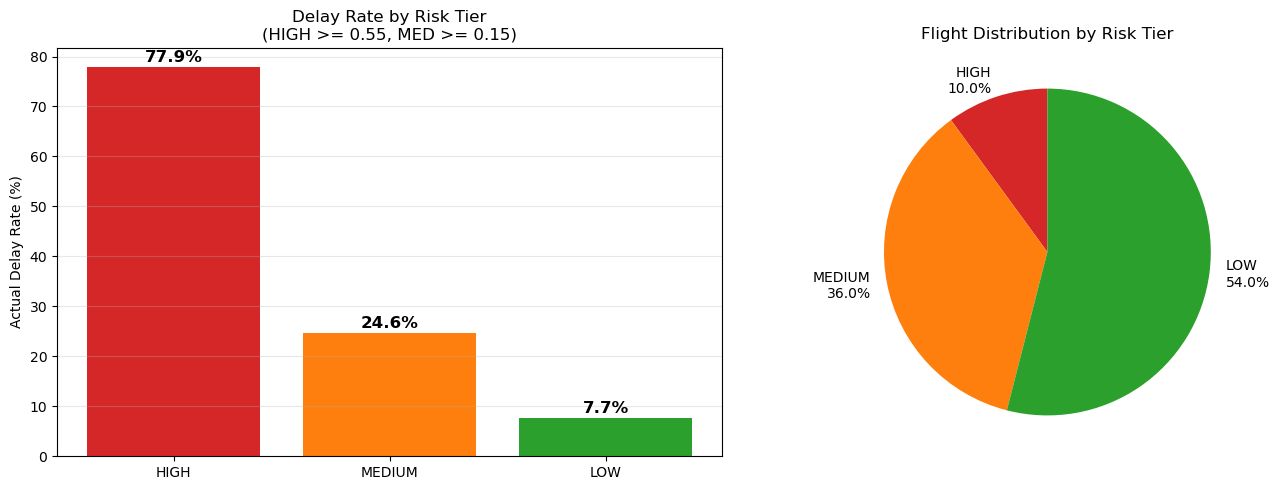

Saved: risk_tier_analysis.png


In [18]:
# --- 3-Tier visualization ---
if best_config:
    high_thresh_final, med_thresh_final = best_config[0], best_config[1]
else:
    # Fallback defaults
    high_thresh_final, med_thresh_final = 0.40, 0.20

tiers = np.where(best_proba_calibrated >= high_thresh_final, 'HIGH',
        np.where(best_proba_calibrated >= med_thresh_final, 'MEDIUM', 'LOW'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: delay rate by tier
tier_data = []
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    mask = tiers == tier
    tier_data.append({
        'tier': tier,
        'count': mask.sum(),
        'share': mask.sum() / len(y_test) * 100,
        'delay_rate': y_test.values[mask].mean() * 100 if mask.sum() > 0 else 0,
    })

tier_df = pd.DataFrame(tier_data)
colors_tier = ['#d62728', '#ff7f0e', '#2ca02c']

axes[0].bar(tier_df['tier'], tier_df['delay_rate'], color=colors_tier)
axes[0].set_ylabel('Actual Delay Rate (%)')
axes[0].set_title(f'Delay Rate by Risk Tier\n(HIGH >= {high_thresh_final:.2f}, MED >= {med_thresh_final:.2f})')
for i, row in tier_df.iterrows():
    axes[0].text(i, row['delay_rate'] + 1, f'{row["delay_rate"]:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart: flight share
axes[1].pie(tier_df['share'], labels=[f'{t}\n{s:.1f}%' for t, s in zip(tier_df['tier'], tier_df['share'])],
            colors=colors_tier, autopct='', startangle=90)
axes[1].set_title('Flight Distribution by Risk Tier')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'risk_tier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: risk_tier_analysis.png')

## 9. Multi-Mode Thresholds

In [19]:
# --- Precision-Recall-F1 vs Threshold ---
print('=' * 75)
print('PRECISION / RECALL / F1 vs THRESHOLD (Production model, raw probabilities)')
print('=' * 75)
print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"TP":>6} {"FP":>6} {"FN":>6} {"TN":>6}')
print('-' * 75)

threshold_table = []
for t in np.arange(0.20, 0.65, 0.05):
    m = evaluate_at_threshold(y_test.values, best_proba, t)
    threshold_table.append({
        'threshold': t,
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
    })
    # Compute confusion matrix
    y_pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f'{t:>10.2f} {m["precision"]*100:>9.1f}% {m["recall"]*100:>9.1f}% '
          f'{m["f1"]*100:>9.1f}% {tp:>6} {fp:>6} {fn:>6} {tn:>6}')

# Also with calibrated probabilities
print('\n--- Same table with CALIBRATED probabilities ---')
print(f'{"Threshold":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 50)
for t in np.arange(0.05, 0.65, 0.05):
    y_pred_cal = (best_proba_calibrated >= t).astype(int)
    if y_pred_cal.sum() == 0:
        continue
    p = precision_score(y_test, y_pred_cal, zero_division=0)
    r = recall_score(y_test, y_pred_cal, zero_division=0)
    f = f1_score(y_test, y_pred_cal, zero_division=0)
    print(f'{t:>10.2f} {p*100:>9.1f}% {r*100:>9.1f}% {f*100:>9.1f}%')

PRECISION / RECALL / F1 vs THRESHOLD (Production model, raw probabilities)
 Threshold  Precision     Recall         F1     TP     FP     FN     TN
---------------------------------------------------------------------------
      0.20      27.9%      91.2%      42.8%   8348  21533    810  13264
      0.25      32.0%      85.8%      46.6%   7857  16680   1301  18117
      0.30      36.2%      80.0%      49.9%   7324  12901   1834  21896
      0.35      40.7%      73.6%      52.4%   6741   9807   2417  24990
      0.40      46.0%      67.5%      54.7%   6183   7268   2975  27529
      0.45      51.5%      61.8%      56.2%   5662   5338   3496  29459
      0.50      57.0%      56.4%      56.7%   5169   3902   3989  30895
      0.55      62.8%      51.6%      56.7%   4724   2794   4434  32003
      0.60      67.3%      46.6%      55.1%   4266   2069   4892  32728

--- Same table with CALIBRATED probabilities ---
 Threshold  Precision     Recall         F1
-----------------------------------

### 9.1 Operating Modes

In [20]:
# === Multi-Mode Threshold Search ===
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.90, 0.01)
best_proba_for_thresh = best_proba  # production model probabilities

mode_results = {}

for t in thresholds:
    y_pred = (best_proba_for_thresh >= t).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f = f1_score(y_test, y_pred, zero_division=0)
    
    # Balanced: maximize F1 where R≥65% and P≥30%
    if r >= 0.65 and p >= 0.40:
        if 'Balanced (Default)' not in mode_results or f > mode_results['Balanced (Default)']['f1']:
            mode_results['Balanced (Default)'] = {'threshold': t, 'precision': p, 'recall': r, 'f1': f}
    
    # High Precision: maximize Precision where R≥50%
    if r >= 0.60:
        if 'High Precision' not in mode_results or p > mode_results['High Precision']['precision']:
            mode_results['High Precision'] = {'threshold': t, 'precision': p, 'recall': r, 'f1': f}
    
    # High Recall: maximize Recall where P≥20%
    if p >= 0.30:
        if 'High Recall' not in mode_results or r > mode_results['High Recall']['recall']:
            mode_results['High Recall'] = {'threshold': t, 'precision': p, 'recall': r, 'f1': f}

print("=" * 70)
print("MULTI-MODE THRESHOLD RECOMMENDATIONS")
print("=" * 70)
descriptions = {
    'Balanced (Default)': 'Standard operations. Catches most delays with manageable false alarm rate.',
    'High Precision': 'Minimize false alarms. Use during normal/low-traffic periods.',
    'High Recall': 'Catch nearly all delays. Use during severe weather.',
}
for mode in ['Balanced (Default)', 'High Precision', 'High Recall']:
    if mode in mode_results:
        m = mode_results[mode]
        print(f"\n{mode}:")
        print(f"  {descriptions[mode]}")
        print(f"  Threshold: {m['threshold']:.2f}")
        print(f"  Precision: {m['precision']*100:.1f}%, Recall: {m['recall']*100:.1f}%, F1: {m['f1']*100:.1f}%")
    else:
        print(f"\n{mode}: No valid threshold found")

# Production threshold = Balanced
if 'Balanced (Default)' in mode_results:
    optimal_threshold = mode_results['Balanced (Default)']['threshold']
    print(f"\nProduction threshold (Balanced): {optimal_threshold:.2f}")


MULTI-MODE THRESHOLD RECOMMENDATIONS

Balanced (Default):
  Standard operations. Catches most delays with manageable false alarm rate.
  Threshold: 0.42
  Precision: 47.9%, Recall: 65.1%, F1: 55.2%

High Precision:
  Minimize false alarms. Use during normal/low-traffic periods.
  Threshold: 0.46
  Precision: 52.6%, Recall: 60.7%, F1: 56.3%

High Recall:
  Catch nearly all delays. Use during severe weather.
  Threshold: 0.23
  Precision: 30.4%, Recall: 88.2%, F1: 45.2%

Production threshold (Balanced): 0.42


## 10. Fallback Model

In [21]:
# --- Define fallback feature set ---
# V9.0: From 19 features, remove all real-time/lag-dependent features → 11 fallback features
lag_congestion_v4lag_aircraft_features = [
    # Core lag (4)
    'delay_rate_1h', 'delay_rolling_3h',
    'severe_delay_count_prev', 'terminal_delay_1h',
    # Operational lag (2)
    'lga_dep_delay_1h', 
    # Aircraft continuity (2)
    'prev_aircraft_delay', 
]

fallback_features = [f for f in feature_columns if f not in lag_congestion_v4lag_aircraft_features]
print(f'Fallback features: {len(fallback_features)} (removed {len([f for f in lag_congestion_v4lag_aircraft_features if f in feature_columns])} lag+operational+aircraft)')
print(f'Retained: target encoded, weather, weather impact, network, time')
for f in fallback_features:
    print(f'  {f}')

Fallback features: 15 (removed 6 lag+operational+aircraft)
Retained: target encoded, weather, weather impact, network, time
  turnaround_hours
  gate_delay_rate
  faa_delay_reason
  runway_delay_rate
  airline_delay_rate
  Hour
  faa_delay_severity
  runway_config_change
  origin_dewpoint
  origin_historical_delay
  origin_wx_impact
  route_risk_score
  lga_wx_impact
  faa_event_duration_hours
  faa_active_event_count


### 10.1 Train Fallback

In [22]:
# --- Train fallback models (no lag, no aircraft features) ---
X_train_fb = X_train[fallback_features]
X_test_fb = X_test[fallback_features]

# LGB fallback
lgb_fallback = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=3.5, random_state=42, verbose=-1
)
lgb_fallback.fit(X_train_fb, y_train)
lgb_fb_proba = lgb_fallback.predict_proba(X_test_fb)[:, 1]
lgb_fb_auc = roc_auc_score(y_test, lgb_fb_proba)
print(f'Fallback LGB AUC:      {lgb_fb_auc:.4f}')

# XGB fallback
from xgboost import XGBClassifier
xgb_fallback = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=3.5, random_state=42, verbosity=0
)
xgb_fallback.fit(X_train_fb, y_train)
xgb_fb_proba = xgb_fallback.predict_proba(X_test_fb)[:, 1]
xgb_fb_auc = roc_auc_score(y_test, xgb_fb_proba)
print(f'Fallback XGB AUC:      {xgb_fb_auc:.4f}')

# CatBoost fallback
cat_fallback = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
cat_fallback.fit(X_train_fb, y_train)
cat_fb_proba = cat_fallback.predict_proba(X_test_fb)[:, 1]
cat_fb_auc = roc_auc_score(y_test, cat_fb_proba)
prod_auc = model_aucs[best_model_name] if 'model_aucs' in dir() else 0
print(f'Fallback CatBoost AUC: {cat_fb_auc:.4f} (vs production {prod_auc:.4f}, delta={cat_fb_auc-prod_auc:.4f})')

# Select best fallback
fb_results = [
    ('LGB', lgb_fallback, lgb_fb_auc, lgb_fb_proba),
    ('XGB', xgb_fallback, xgb_fb_auc, xgb_fb_proba),
    ('CatBoost', cat_fallback, cat_fb_auc, cat_fb_proba),
]
best_fb = max(fb_results, key=lambda x: x[2])
fb_model_name = best_fb[0]
fb_model = best_fb[1]
fb_final_auc = best_fb[2]
fb_final_proba = best_fb[3]
print(f'\nBest fallback: {fb_model_name} (AUC={fb_final_auc:.4f})')


Fallback LGB AUC:      0.7783
Fallback XGB AUC:      0.7768
Fallback CatBoost AUC: 0.7807 (vs production 0.8094, delta=-0.0287)

Best fallback: CatBoost (AUC=0.7807)


## 11. 4-Tier Risk System

In [23]:
# --- 4-Tier Risk Grid Search ---
def evaluate_4tier_risk(y_true, y_proba, crit_t, high_t, med_t):
    """Evaluate a 4-tier risk configuration."""
    tiers = np.where(y_proba >= crit_t, 'CRITICAL',
            np.where(y_proba >= high_t, 'HIGH',
            np.where(y_proba >= med_t, 'MEDIUM', 'LOW')))

    results = {}
    for tier in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
        mask = tiers == tier
        n = mask.sum()
        if n > 0:
            results[tier] = {
                'count': int(n),
                'share': n / len(y_true),
                'delay_rate': float(y_true[mask].mean()),
            }
        else:
            results[tier] = {'count': 0, 'share': 0, 'delay_rate': 0}

    crit_rate = results['CRITICAL']['delay_rate']
    low_rate = results['LOW']['delay_rate']
    separation = crit_rate / low_rate if low_rate > 0 else float('inf')
    return results, separation

# Grid search over 4-tier thresholds
print('=' * 100)
print('4-TIER RISK GRID SEARCH (calibrated probabilities)')
print('=' * 100)
print(f'{"CRIT_t":>7} {"HIGH_t":>7} {"MED_t":>7} '
      f'{"C_sh":>6} {"C_del":>6} {"H_sh":>6} {"H_del":>6} '
      f'{"M_sh":>6} {"M_del":>6} {"L_sh":>6} {"L_del":>6} {"Sep":>6}')
print('-' * 100)

best_4tier = None
best_4tier_sep = 0

for crit_t in np.arange(0.55, 0.86, 0.05):
    for high_t in np.arange(0.30, 0.56, 0.05):
        for med_t in np.arange(0.10, 0.31, 0.05):
            if med_t >= high_t or high_t >= crit_t:
                continue

            results, sep = evaluate_4tier_risk(y_test.values, best_proba_calibrated, crit_t, high_t, med_t)
            c = results['CRITICAL']
            h = results['HIGH']
            m = results['MEDIUM']
            l = results['LOW']

            # Constraints:
            #   CRITICAL delay >= 60%, HIGH delay >= 35%, LOW delay <= 10%
            #   Separation (CRITICAL/LOW) >= 8x
            #   CRITICAL share >= 2% (enough flights to be useful)
            #   MEDIUM share <= 40%
            if (c['delay_rate'] >= 0.60
                and h['delay_rate'] >= 0.35
                and l['delay_rate'] <= 0.10
                and sep >= 8.0
                and c['share'] >= 0.02
                and m['share'] <= 0.40):

                if sep > best_4tier_sep:
                    best_4tier_sep = sep
                    best_4tier = (crit_t, high_t, med_t, results, sep)

# Print top result
if best_4tier:
    crit_t, high_t, med_t, results, sep = best_4tier
    print(f'\nBest 4-tier config:')
    print(f'  CRITICAL >= {crit_t:.2f}, HIGH >= {high_t:.2f}, MEDIUM >= {med_t:.2f}')
    print(f'  Separation (CRITICAL/LOW): {sep:.1f}x')
    for tier_name in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
        r = results[tier_name]
        print(f'  {tier_name:<10}: {r["share"]*100:>5.1f}% of flights, '
              f'{r["delay_rate"]*100:>5.1f}% delay rate, {r["count"]:>5} flights')

    # Also show some near-best alternatives
    print('\n--- Top alternative configurations ---')
    alt_configs = []
    for crit_t2 in np.arange(0.55, 0.86, 0.05):
        for high_t2 in np.arange(0.30, 0.56, 0.05):
            for med_t2 in np.arange(0.10, 0.31, 0.05):
                if med_t2 >= high_t2 or high_t2 >= crit_t2:
                    continue
                results2, sep2 = evaluate_4tier_risk(y_test.values, best_proba_calibrated, crit_t2, high_t2, med_t2)
                c2, l2 = results2['CRITICAL'], results2['LOW']
                if (c2['delay_rate'] >= 0.60 and results2['HIGH']['delay_rate'] >= 0.35
                    and l2['delay_rate'] <= 0.10 and sep2 >= 8.0 and c2['share'] >= 0.02
                    and results2['MEDIUM']['share'] <= 0.40):
                    alt_configs.append((crit_t2, high_t2, med_t2, results2, sep2))

    alt_configs.sort(key=lambda x: x[4], reverse=True)
    for cfg in alt_configs[:5]:
        ct, ht, mt, res, sp = cfg
        print(f'  CRIT>={ct:.2f} HIGH>={ht:.2f} MED>={mt:.2f} | '
              f'C:{res["CRITICAL"]["share"]*100:.1f}%/{res["CRITICAL"]["delay_rate"]*100:.0f}% '
              f'H:{res["HIGH"]["share"]*100:.1f}%/{res["HIGH"]["delay_rate"]*100:.0f}% '
              f'L:{res["LOW"]["share"]*100:.1f}%/{res["LOW"]["delay_rate"]*100:.0f}% '
              f'Sep:{sp:.1f}x')
else:
    print('\nNo 4-tier config met all constraints')

4-TIER RISK GRID SEARCH (calibrated probabilities)
 CRIT_t  HIGH_t   MED_t   C_sh  C_del   H_sh  H_del   M_sh  M_del   L_sh  L_del    Sep
----------------------------------------------------------------------------------------------------

Best 4-tier config:
  CRITICAL >= 0.80, HIGH >= 0.30, MEDIUM >= 0.15
  Separation (CRITICAL/LOW): 12.1x
  CRITICAL  :   4.0% of flights,  93.6% delay rate,  1747 flights
  HIGH      :  13.9% of flights,  52.4% delay rate,  6090 flights
  MEDIUM    :  28.2% of flights,  20.2% delay rate, 12387 flights
  LOW       :  54.0% of flights,   7.7% delay rate, 23731 flights

--- Top alternative configurations ---
  CRIT>=0.80 HIGH>=0.30 MED>=0.15 | C:4.0%/94% H:13.9%/52% L:54.0%/8% Sep:12.1x
  CRIT>=0.80 HIGH>=0.35 MED>=0.15 | C:4.0%/94% H:13.0%/54% L:54.0%/8% Sep:12.1x
  CRIT>=0.80 HIGH>=0.40 MED>=0.15 | C:4.0%/94% H:10.6%/57% L:54.0%/8% Sep:12.1x
  CRIT>=0.80 HIGH>=0.45 MED>=0.15 | C:4.0%/94% H:7.2%/65% L:54.0%/8% Sep:12.1x
  CRIT>=0.80 HIGH>=0.50 MED>=0.15

### 11.1 Fallback Evaluation

In [24]:
# --- Fallback evaluation ---
# fb_model, fb_model_name, fb_final_auc, fb_final_proba already set in previous cell

# Threshold analysis for fallback
fb_t, fb_m = find_optimal_threshold(y_test.values, fb_final_proba, target_recall=0.55, min_precision=0.30)
print(f'Fallback at recall >= 55%:')
print(f'  Threshold: {fb_t:.2f}')
print(f'  Precision: {fb_m["precision"]:.4f}')
print(f'  Recall:    {fb_m["recall"]:.4f}')
print(f'  F1:        {fb_m["f1"]:.4f}')

# Multi-threshold
print(f'\nFallback multi-threshold:')
for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    m = evaluate_at_threshold(y_test.values, fb_final_proba, t)
    print(f'  t={t:.2f}: P={m["precision"]:.4f}, R={m["recall"]:.4f}, F1={m["f1"]:.4f}')


Fallback at recall >= 55%:
  Threshold: 0.52
  Precision: 0.4972
  Recall:    0.5518
  F1:        0.5231

Fallback multi-threshold:
  t=0.30: P=0.2747, R=0.8962, F1=0.4205
  t=0.35: P=0.3133, R=0.8279, F1=0.4546
  t=0.40: P=0.3562, R=0.7455, F1=0.4821
  t=0.45: P=0.4080, R=0.6572, F1=0.5035
  t=0.50: P=0.4706, R=0.5810, F1=0.5200


### 11.2 4-Tier Visualization

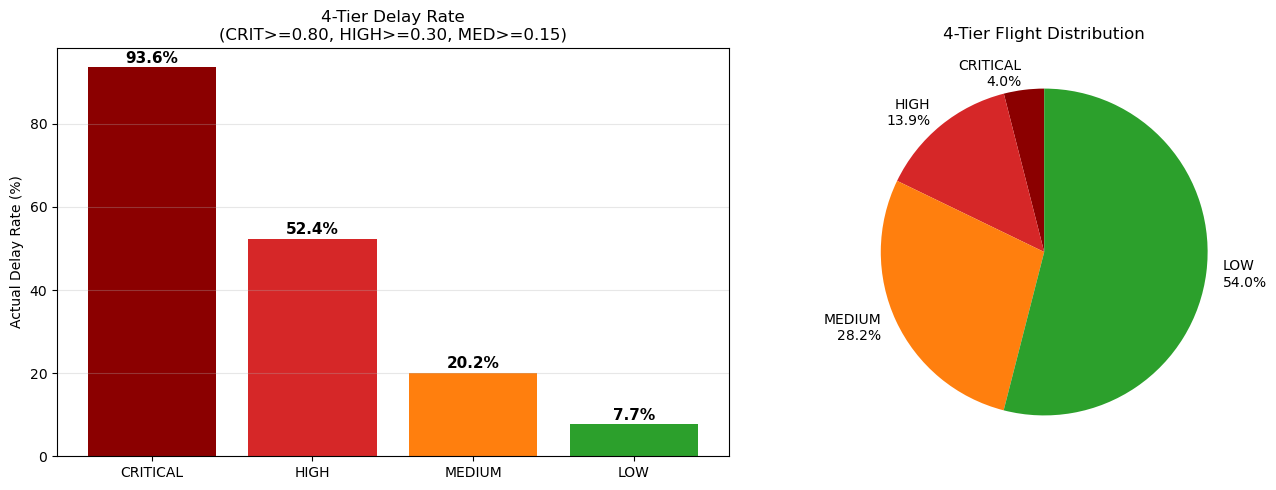

Saved: risk_tier_4tier_analysis.png


In [25]:
# --- 4-Tier Visualization ---
if best_4tier:
    crit_thresh, high_thresh_4t, med_thresh_4t = best_4tier[0], best_4tier[1], best_4tier[2]
    results_4t = best_4tier[3]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    tier_names_4 = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
    colors_4tier = ['#8b0000', '#d62728', '#ff7f0e', '#2ca02c']

    # Bar chart: delay rate by tier
    delay_rates = [results_4t[t]['delay_rate'] * 100 for t in tier_names_4]
    axes[0].bar(tier_names_4, delay_rates, color=colors_4tier)
    axes[0].set_ylabel('Actual Delay Rate (%)')
    axes[0].set_title(f'4-Tier Delay Rate\n(CRIT>={crit_thresh:.2f}, HIGH>={high_thresh_4t:.2f}, MED>={med_thresh_4t:.2f})')
    for i, (name, rate) in enumerate(zip(tier_names_4, delay_rates)):
        axes[0].text(i, rate + 1, f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    # Pie chart: flight share
    shares = [results_4t[t]['share'] * 100 for t in tier_names_4]
    axes[1].pie(shares, labels=[f'{n}\n{s:.1f}%' for n, s in zip(tier_names_4, shares)],
                colors=colors_4tier, autopct='', startangle=90)
    axes[1].set_title('4-Tier Flight Distribution')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'risk_tier_4tier_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: risk_tier_4tier_analysis.png')
else:
    print('Skipping 4-tier visualization (no valid config found)')

## 12. Lookahead Degradation

In [26]:
# --- Lookahead simulation ---
# Lag features that degrade with lookahead (computed from rolling time windows)
# V9.0: 6 lag features (same as V7.0, minus delay_rolling_1h, arrivals_prev_1h,
#        avg_taxi_in_1h, lga_capacity_util from V6.0's 10)
lag_features_lookahead = [
    'delay_rate_1h', 'delay_rolling_3h',
    'severe_delay_count_prev', 'terminal_delay_1h',
    'lga_dep_delay_1h', 
]
# Filter to features that actually exist in X_test
lag_features_lookahead = [f for f in lag_features_lookahead if f in X_test.columns]
print(f'Lag features subject to lookahead degradation: {len(lag_features_lookahead)}')
print(f'Non-lag features (stable): {len(feature_columns) - len(lag_features_lookahead)}')

# Compute average flights per hour in test set (for shift calibration)
test_date_col = test['Date'].dt.date
flights_per_day = test_date_col.value_counts().mean()
flights_per_hour = flights_per_day / 16  # ~16 operating hours (5am-9pm)
print(f'Avg flights/hour in test: {flights_per_hour:.1f}')

# Train medians for filling NaN after shift
train_medians = X_train.median()

# Production model for re-prediction
prod_model = cat_tuned  # CatBoost Optuna (depth≤12)

# Simulate each lookahead window
lookahead_results = []
for lookahead_h in [0, 1, 2, 3, 4, 5]:
    shift_n = int(round(flights_per_hour * lookahead_h))

    X_shifted = X_test.copy()

    if shift_n > 0:
        # Within each date, shift lag features backward by shift_n positions
        # This simulates: "at prediction time, lag data is ~lookahead_h hours old"
        for col in lag_features_lookahead:
            X_shifted[col] = X_shifted.groupby(test_date_col)[col].shift(shift_n)
        # NaN = first flights of day with no earlier lag data → fill with train median
        X_shifted = X_shifted.fillna(train_medians)

    # Re-predict with (potentially degraded) features
    proba = prod_model.predict_proba(X_shifted)[:, 1]
    auc = roc_auc_score(y_test, proba)

    # Precision at recall >= 65%
    t_opt, m = find_optimal_threshold(y_test.values, proba, target_recall=0.65, min_precision=0.25)

    lookahead_results.append({
        'lookahead_h': lookahead_h,
        'shift_flights': shift_n,
        'auc': auc,
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'threshold': t_opt,
    })

# Display results
print('\n' + '=' * 80)
print('LOOKAHEAD WINDOW EVALUATION')
print('=' * 80)
print(f'{"Lookahead":>10} {"Shift":>8} {"AUC":>8} {"Prec":>8} {"Recall":>8} {"F1":>8} {"Thresh":>8} {"ΔAUC":>8}')
print('-' * 80)
base_auc = lookahead_results[0]['auc']
for r in lookahead_results:
    delta = r['auc'] - base_auc
    print(f'{r["lookahead_h"]:>8}h {r["shift_flights"]:>8} {r["auc"]:>8.4f} '
          f'{r["precision"]:>8.4f} {r["recall"]:>8.4f} {r["f1"]:>8.4f} '
          f'{r["threshold"]:>8.2f} {delta:>+8.4f}')

# Fallback comparison
print(f'\n  Fallback (no lag): AUC={fb_final_auc:.4f} (ΔAUC={fb_final_auc - base_auc:+.4f})')
print(f'  → Fallback represents the theoretical floor (infinite lookahead)')

Lag features subject to lookahead degradation: 5
Non-lag features (stable): 16
Avg flights/hour in test: 31.2

LOOKAHEAD WINDOW EVALUATION
 Lookahead    Shift      AUC     Prec   Recall       F1   Thresh     ΔAUC
--------------------------------------------------------------------------------
       0h        0   0.8094   0.4793   0.6508   0.5520     0.42  +0.0000
       1h       31   0.7357   0.3585   0.6513   0.4625     0.36  -0.0737
       2h       62   0.7397   0.3649   0.6567   0.4691     0.36  -0.0697
       3h       94   0.7430   0.3694   0.6580   0.4731     0.36  -0.0664
       4h      125   0.7455   0.3786   0.6506   0.4787     0.37  -0.0639
       5h      156   0.7389   0.3650   0.6584   0.4696     0.36  -0.0705

  Fallback (no lag): AUC=0.7807 (ΔAUC=-0.0287)
  → Fallback represents the theoretical floor (infinite lookahead)


### 12.1 Degradation Curve

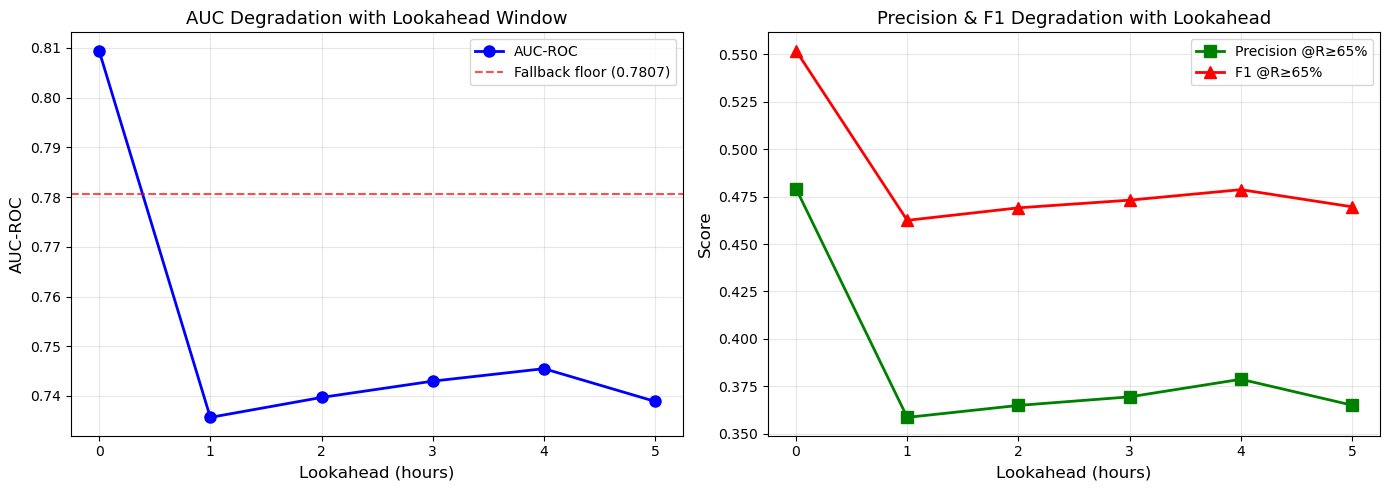

Saved: lookahead_degradation.png

Summary:
  0h → 3h: ΔAUC = -0.0664 (8.2% relative)
  0h → 5h: ΔAUC = -0.0705 (8.7% relative)
  Fallback:  ΔAUC = -0.0287

  → Significant degradation even at 3h
  → Consider: (1) separate short/long-term models, or (2) fallback for 4-5h window


In [27]:
# --- Lookahead degradation curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hours = [r['lookahead_h'] for r in lookahead_results]
aucs = [r['auc'] for r in lookahead_results]
precs = [r['precision'] for r in lookahead_results]
f1s = [r['f1'] for r in lookahead_results]

# AUC degradation
axes[0].plot(hours, aucs, 'bo-', linewidth=2, markersize=8, label='AUC-ROC')
axes[0].axhline(y=fb_final_auc, color='red', linestyle='--', alpha=0.7,
                label=f'Fallback floor ({fb_final_auc:.4f})')
axes[0].set_xlabel('Lookahead (hours)', fontsize=12)
axes[0].set_ylabel('AUC-ROC', fontsize=12)
axes[0].set_title('AUC Degradation with Lookahead Window', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(6))

# Precision & F1 degradation
axes[1].plot(hours, precs, 'gs-', linewidth=2, markersize=8, label='Precision @R≥65%')
axes[1].plot(hours, f1s, 'r^-', linewidth=2, markersize=8, label='F1 @R≥65%')
axes[1].set_xlabel('Lookahead (hours)', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision & F1 Degradation with Lookahead', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(6))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lookahead_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lookahead_degradation.png')

# Summary interpretation
auc_drop_3h = lookahead_results[3]['auc'] - lookahead_results[0]['auc']
auc_drop_5h = lookahead_results[5]['auc'] - lookahead_results[0]['auc']
print(f'\nSummary:')
print(f'  0h → 3h: ΔAUC = {auc_drop_3h:+.4f} ({abs(auc_drop_3h/lookahead_results[0]["auc"])*100:.1f}% relative)')
print(f'  0h → 5h: ΔAUC = {auc_drop_5h:+.4f} ({abs(auc_drop_5h/lookahead_results[0]["auc"])*100:.1f}% relative)')
print(f'  Fallback:  ΔAUC = {fb_final_auc - lookahead_results[0]["auc"]:+.4f}')

if abs(auc_drop_5h) < 0.03:
    print(f'\n  → 5h lookahead AUC drop < 3pp: model is robust for 4-5h predictions')
    print(f'  → Dashboard can show all predictions without confidence disclaimers')
elif abs(auc_drop_3h) < 0.03:
    print(f'\n  → 3h lookahead is safe (< 3pp drop), but 5h shows significant degradation')
    print(f'  → Dashboard: mark 4-5h predictions as "lower confidence"')
else:
    print(f'\n  → Significant degradation even at 3h')
    print(f'  → Consider: (1) separate short/long-term models, or (2) fallback for 4-5h window')

## 13. Save Production Models

In [28]:
# --- Save production model ---
# Determine best model to save
if 'CatBoost' in best_model_name:
    production_model = cat_tuned
    production_params = cat_best_params
    best_trial_params = study_cat.best_params
else:
    production_model = lgb_tuned
    production_params = lgb_best_params
    best_trial_params = study_lgb.best_params

best_auc = model_aucs[best_model_name]

# Optimal threshold for production (balanced mode)
prod_t, prod_m = find_optimal_threshold(y_test.values, best_proba, target_recall=0.65, min_precision=0.30)

# Build temporal decay config from the best Optuna trial
temporal_decay_config = {
    'use_temporal': best_trial_params.get('use_temporal', False),
    'half_life': best_trial_params.get('half_life', None),
}

# Save main model
model_path = MODELS_DIR / 'production_model_v9_0.joblib'
joblib.dump({
    'model': production_model,
    'model_type': best_model_name,
    'best_params': production_params,
    'auc': best_auc,
    'optimal_threshold': prod_t,
    'metrics_at_threshold': prod_m,
    'feature_columns': feature_columns,
    'train_medians': train_medians.to_dict(),
    'gate_target_encoding': gate_target.to_dict(),
    'terminal_target_encoding': terminal_target.to_dict(),
    'airline_target_encoding': airline_target.to_dict(),
    'runway_target_encoding': runway_target.to_dict() if 'runway_target' in dir() else {},
    'faa_reason_target_encoding': faa_reason_target.to_dict() if 'faa_reason_target' in dir() else {},
    'train_delay_rate': float(y_train.mean()),
    'split_cutoff': str(cutoff),
    'temporal_decay': temporal_decay_config,
    'operating_modes': {
        name: {'threshold': r['threshold'], 'precision': r['precision'], 'recall': r['recall'], 'f1': r['f1']}
        for name, r in mode_results.items()
    },
    'version': 'v9_0',
}, model_path)
print(f'Saved: {model_path}')
print(f'  temporal_decay: {temporal_decay_config}')

# Save calibrator
cal_path = MODELS_DIR / 'calibrator_v9_0.joblib'
joblib.dump(production_calibrator, cal_path)
print(f'Saved: {cal_path}')

# Save fallback model
fb_path = MODELS_DIR / 'fallback_model_v9_0.joblib'
joblib.dump({
    'model': fb_model,
    'model_type': fb_model_name,
    'auc': fb_final_auc,
    'feature_columns': fallback_features,
    'optimal_threshold': fb_t,
    'metrics_at_threshold': fb_m,
    'version': 'v9_0',
}, fb_path)
print(f'Saved: {fb_path}')

Saved: ../../../models/production_model_v9_0.joblib
  temporal_decay: {'use_temporal': True, 'half_life': 59.74499938159364}
Saved: ../../../models/calibrator_v9_0.joblib
Saved: ../../../models/fallback_model_v9_0.joblib


### 13.1 Save Config

In [29]:
# --- Save configuration ---
config = {
    'model_type': best_model_name,
    'version': 'v9_0',
    'auc': float(best_auc),
    'features': feature_columns,
    'n_features': len(feature_columns),
    'optimal_threshold': float(prod_t),
    'metrics': {
        'precision': float(prod_m['precision']),
        'recall': float(prod_m['recall']),
        'f1': float(prod_m['f1']),
    },
    'operating_modes': {
        name: {
            'threshold': float(r['threshold']),
            'precision': float(r['precision']),
            'recall': float(r['recall']),
            'f1': float(r['f1']),
        }
        for name, r in mode_results.items()
    },
    'risk_tiers_3tier': {
        'HIGH': {
            'threshold': float(high_thresh_final),
            'description': 'High confidence delay - take immediate action',
        },
        'MEDIUM': {
            'threshold': float(med_thresh_final),
            'description': 'Possible delay - monitor closely',
        },
        'LOW': {
            'threshold': 0.0,
            'description': 'Likely on-time',
        },
    },
    'risk_tiers_4tier': {
        'CRITICAL': {
            'threshold': float(best_4tier[0]) if best_4tier else None,
            'description': 'Very high confidence delay - immediate action required',
        },
        'HIGH': {
            'threshold': float(best_4tier[1]) if best_4tier else None,
            'description': 'High confidence delay - prepare proactively',
        },
        'MEDIUM': {
            'threshold': float(best_4tier[2]) if best_4tier else None,
            'description': 'Possible delay - monitor',
        },
        'LOW': {
            'threshold': 0.0,
            'description': 'Likely on-time - normal operations',
        },
    } if best_4tier else None,
    'calibrated': True,
    'fallback': {
        'model_type': fb_model_name,
        'auc': float(fb_final_auc),
        'features': fallback_features,
        'n_features': len(fallback_features),
    },
    'data': {
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test)),
        'train_delay_rate': float(y_train.mean()),
        'test_delay_rate': float(y_test.mean()),
        'split_cutoff': str(cutoff),
    },
}

config_path = PROJECT_ROOT / 'outputs' / 'model_config_v9_0.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved: {config_path}')

Saved: ../../../outputs/model_config_v9_0.json


### 13.2 Save Optuna Studies

In [30]:
# --- Save Optuna studies ---
study_path = MODELS_DIR / 'optuna_studies_v9_0.pkl'
with open(study_path, 'wb') as f:
    pickle.dump({'lgb': study_lgb, 'catboost': study_cat}, f)
print(f'Saved: {study_path}')

Saved: ../../../models/optuna_studies_v9_0.pkl


## 14. Summary

In [31]:
# --- Final summary ---
print('\n' + '=' * 80)
print('NOTEBOOK 06 SUMMARY (V9.0: 21 features)')
print('=' * 80)

print(f'\n--- Model Performance ---')
print(f'{"Model":<40} {"AUC":>8}')
print('-' * 50)
for name, proba in all_models.items():
    auc = roc_auc_score(y_test, proba)
    marker = ' <-- BEST' if name == best_model_name else ''
    print(f'{name:<40} {auc:>8.4f}{marker}')

print(f'\n--- Production Model ---')
print(f'Model:     {best_model_name}')
print(f'AUC:       {best_auc:.4f}')
print(f'Features:  {len(feature_columns)}')
print(f'Threshold: {prod_t:.2f} (Balanced mode)')
print(f'Precision: {prod_m["precision"]*100:.1f}%')
print(f'Recall:    {prod_m["recall"]*100:.1f}%')
print(f'F1:        {prod_m["f1"]*100:.1f}%')

print(f'\n--- Operating Modes ---')
for mode_name, result in mode_results.items():
    m = result
    print(f'  {mode_name}: t={result["threshold"]:.2f}, '
          f'P={m["precision"]*100:.1f}%, R={m["recall"]*100:.1f}%, F1={m["f1"]*100:.1f}%')

print(f'\n--- Risk Tiers (3-tier) ---')
print(f'HIGH >= {high_thresh_final:.2f}, MEDIUM >= {med_thresh_final:.2f}')
for tier_info in tier_data:
    print(f'  {tier_info["tier"]}: {tier_info["share"]:.1f}% of flights, {tier_info["delay_rate"]:.1f}% delay rate')

if best_4tier:
    ct, ht, mt = best_4tier[0], best_4tier[1], best_4tier[2]
    r4 = best_4tier[3]
    print(f'\n--- Risk Tiers (4-tier) ---')
    print(f'CRITICAL >= {ct:.2f}, HIGH >= {ht:.2f}, MEDIUM >= {mt:.2f}')
    for tier_name in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
        r = r4[tier_name]
        print(f'  {tier_name}: {r["share"]*100:.1f}% of flights, {r["delay_rate"]*100:.1f}% delay rate')

print(f'\n--- Fallback Model ---')
print(f'Type:      {fb_model_name}')
print(f'AUC:       {fb_final_auc:.4f}')
print(f'Features:  {len(fallback_features)} (no lag/operational/aircraft)')

print(f'\n--- Saved Files ---')
print(f'  {model_path}')
print(f'  {cal_path}')
print(f'  {fb_path}')
print(f'  {config_path}')
print(f'  {study_path}')


NOTEBOOK 06 SUMMARY (V9.0: 21 features)

--- Model Performance ---
Model                                         AUC
--------------------------------------------------
LGB baseline (spw=4.0)                     0.8056
XGB baseline (spw=4.0)                     0.8057
CatBoost baseline (balanced)               0.8038
LGB Optuna                                 0.8082
XGB Optuna                                 0.8087
CatBoost Optuna (depth≤12) (depth<=12)     0.8094 <-- BEST

--- Production Model ---
Model:     CatBoost Optuna (depth≤12) (depth<=12)
AUC:       0.8094
Features:  21
Threshold: 0.42 (Balanced mode)
Precision: 47.9%
Recall:    65.1%
F1:        55.2%

--- Operating Modes ---
  High Precision: t=0.46, P=52.6%, R=60.7%, F1=56.3%
  High Recall: t=0.23, P=30.4%, R=88.2%, F1=45.2%
  Balanced (Default): t=0.42, P=47.9%, R=65.1%, F1=55.2%

--- Risk Tiers (3-tier) ---
HIGH >= 0.55, MEDIUM >= 0.15
  HIGH: 10.0% of flights, 77.9% delay rate
  MEDIUM: 36.0% of flights, 24.6% delay rate
